In [ ]:
pip install qiskit qiskit-aer pylatexenc qiskit-ibm-runtime

Parameterized circuits in Qiskit are used to create flexible quantum algorithms that can adapt to different tasks by tuning their parameters. we start by Identifying:

*   **Parameter class** and its attributes and methods
*   **Quantum circuits** and how to use parameters in it.
*   **Parameter expressions** and when to use them.

In [ ]:
import numpy as np
from qiskit.circuit import QuantumCircuit, Parameter

In Qiskit, the `Parameter` class allows you to create symbolic variables that can be used in quantum circuits. These parameters remain unbound until circuit execution, enabling the creation of parameterized quantum circuits.

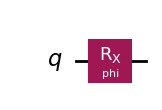

In [ ]:
phi = Parameter('phi')
qc = QuantumCircuit(1)

# use parameter in place of numeric values in quantum gates
# The circuit remains unbound until parameters are assigned
qc.rx(phi, 0)
qc.draw('mpl')


The parameters are then assigned values after the circuit is created. The same ciruict can then be run multiple times with different parameter values.

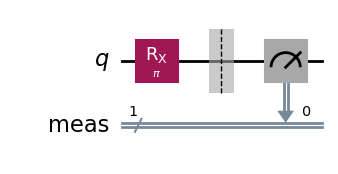

In [ ]:
# bind the parameters after circuit to create a bound circuit
# it can be assigned on the same circuit or a copy of it

qc = qc.assign_parameters({phi: np.pi})
qc.measure_all()

qc.draw('mpl')

| Attribute | Description | Notes |
|-----------|-------------|----------------|
| **`name`** | Parameter name |  |
| **`uuid`** | Parameter identifier |  |


In [ ]:
print(f"Parameter name: {phi.name}")
print(f"Parameter UUID: {phi.uuid}")

Parameter name: phi
Parameter UUID: 2f164eb0-a69b-4f96-935f-2f703699e190


* **abs** : absoulte value of the parameter.
* **arccos**: Arccosine of the parameter.
* **arcsin**: Arcsine of the parameter.
* **arctan**: Arctangent of the parameter.
* **assign**: assign one paramter to a value.
* **bind**: bind parameters to their values.
* **conjugate**: complex conjugate of the parameter.
* **cos**: cosine of the parameter.
* **exp**: exponentiate of the parameter.
* **gradient**: derivative with respect to input parameter.
* **is_real**: checks if the parameter is a real number.
* **log** : natural logarithm of the parameter.
* **numeric**: cast the parameter to a numeric value.
* **sign**: return the sign of the parameter.
* **sin**: sine of the parameter.
* **subs**: returen a new expression with replacement parameters.
* **sympify**: a SymPy equivalent of the paramater.
* **tan**: tangent of the parameter.

In [ ]:
print(phi.sin())
print(phi.cos())
print(phi.tan())

sin(phi)
cos(phi)
tan(phi)


QUANTUM CIRCUIT

The `QuantumCircuit` class is a fundamental building block for quantum programs in Qiskit. It represents a collection of quantum gates and operations.

Parameters can be used across different qubits and gate types, additionally circuits can contain multiple parameters.

The example below shows a circuit with multiple parameters, to get all unbound parameters in a circuit, you can use `parameters` attribute.

ParameterView([Parameter(γ), Parameter(θ)])


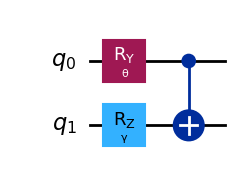

In [ ]:
# Create a multi-parameter circuit

theta = Parameter('θ')
gamma = Parameter('γ')

qc2 = QuantumCircuit(2)
qc2.ry(theta, 0)
qc2.rz(gamma, 1)
qc2.cx(0,1)

print(qc2.parameters)
qc2.draw('mpl')

Use ```dict``` types to bind multiple parameters to values

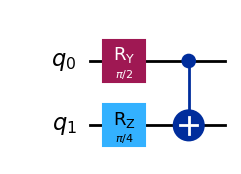

In [ ]:
# Multiple ways to bind parameters

param_dictionary = {theta: np.pi/2, gamma: np.pi/4}

#assign_parameters (returns new circuit)

bound_circuit = qc2.assign_parameters(param_dictionary)

bound_circuit.draw('mpl')

Parmeter Expression

`ParameterExpression` enables creating mathematical expressions of Parameters, allowing complex parameter relationships and constraints. they are created using standard mathematical operations, additionally expressions can include trigonometric functions, logarithms, and other operations

In [ ]:
from math import exp2
from qiskit.circuit import Parameter

# Create base parameters

x = Parameter('x')
y = Parameter('y')

# Create mathematical expressions

expr1 = x + y
expr2 = 2 * x - y**2
expr3 = np.sin(x) + np.cos(y)

print(expr1)
print(expr2)
print(expr3)
print(expr1.parameters)

x + y
2*x - y**2
sin(x) + cos(y)
{Parameter(y), Parameter(x)}


Parameter expressions can be then used directly in quantum gates, as the circuit will automatically extract all base parameters from expressions, and this enables creating the circuit with dependent parameters

ParameterView([Parameter(α), Parameter(β)])


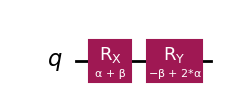

In [ ]:
alpha = Parameter('α')
beta = Parameter('β')

expr = 2 * alpha - beta

qc3 = QuantumCircuit(1)
qc3.rx(alpha + beta, 0)
qc3.ry(expr, 0)

print(qc3.parameters)
qc3.draw('mpl')

More Complex expressions can be created, in this case ```bind()``` method is used to assign the parameter values to the expressions

In [ ]:
# Create and evaluate complex expressions

expr = (x+y) * np.cos(x) - y**2
print(expr)

# Bind parameters and evaluate
param_values = {x: 1.0, y: 2.0}
bound_expr = expr.bind(param_values)
numeric_value = float(bound_expr)

print(bound_expr)
print(numeric_value)

(x + y)*cos(x) - y**2
-2.3790930823955807
-2.3790930823955807
